## Table of Contents
This .ipynb file contains End-to-End Processing of the telco customer churn dataset. The dataset was downloaded from Kaggle. 
1. Imports
2. Loading the data
3. Preprocessing function - FunctionTransformer.
4. Pipeline
5. Threshold Tuning
6. Confusion Matrix

### 1. Imports
- Importing the dependencies. 

In [1]:
import numpy as np
import numpy.typing as npt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline as SKPipeline
from imblearn.pipeline import Pipeline as IMPipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold, TunedThresholdClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score, accuracy_score, r2_score,
    confusion_matrix, 
    RocCurveDisplay, 
    precision_score, 
    classification_report,
    precision_recall_curve
)
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler



### 2. Loading the data. 
- From the csv file at Data directory, or download from kaggle

In [2]:

path = "../Data/telco_customer_churn.csv"
df = pd.read_csv(path)

### 3. Preprocessing function - `FunctionTransformer`. 
- Create a function that encodes and imputes the dataframe. 
- Integrate to scikit-learn using `FunctionTransformer` which gives it `.fit_transform()` property. 
- Chnage the target to numeric, not done in function to avoid leakage. 

In [3]:
def encoding_func(df: pd.DataFrame) -> np.ndarray:
    """Encode The columns and shii.

    Args:
        df (pd.DataFrame): A raw pandas dataframe that has not been preprocessed in any way

    Returns:
        np.ndarray: A numpy array with labels for columns and all columns encoded and imputed. 
    """
    df = df.drop(columns=['customerID'], errors='ignore')
    from sklearn.preprocessing import OneHotEncoder
    yes_no_cols = dict()
    for col in df.columns:
        if df[col].nunique() <= 2:
            yes_no_cols[col] = list(df[col].unique())
    del yes_no_cols['gender']; del yes_no_cols['SeniorCitizen'] # Not Yes/No Columns. 
    for col in yes_no_cols.keys():
        df[col] = df[col].map({'Yes': 1, 'No': 0})

    # Manual Mappings. 
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
    df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
    df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1, 'No': 0, 'No phone service': -1})

    yni = []
    for col in df.columns:
        if col in ['Contract', 'MultipleLines', 'InternetService']: continue # Skip these. 
        if df[col].nunique() == 3:
            yni.append(col)
    for col in yni:
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': -1})

    ohe = OneHotEncoder(sparse_output=False)
    enc = ohe.fit_transform(df[['InternetService', 'PaymentMethod']]) # Nominal Categorical data. 
    temp = pd.DataFrame(enc, columns=ohe.get_feature_names_out())
    df = pd.concat([df.drop(columns=['InternetService', 'PaymentMethod']), temp], axis=1)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # Has NaN values. 
    imp = SimpleImputer(strategy='mean')
    imp_mean = imp.fit_transform(df[['TotalCharges']])
    temp = pd.DataFrame(imp_mean, columns=imp.get_feature_names_out())
    df = pd.concat([df.drop(columns=['TotalCharges']), temp], axis=1)
    arr = np.asarray(df)
    return arr

prep = FunctionTransformer(encoding_func) # Integrate to scikit learn API. 

df['Churn'] = df['Churn'].map({'No': 0, 'Yes':  1}) # Make the target numeric. 


### 4. Scores
- Apply custom function, resample data. 
- Fit and measure metrics - accuracy is not a good tell for imbalanced data

In [4]:
X = prep.fit_transform(df.drop('Churn', axis=1))
y = df['Churn']

X_resampled, y_resampled = SMOTE().fit_resample(X, y)


cv_scores = cross_val_score(GradientBoostingClassifier(random_state=42), X_resampled, y_resampled, scoring='f1', cv=StratifiedKFold(5))
cv_f1 = cv_scores.mean() # F1 from cross validation.

lr = LogisticRegression(max_iter=10000)
lr.fit(X_resampled, y_resampled)
pred = lr.predict(X_resampled)

train_f1 = f1_score(y_resampled, pred)
r2 = r2_score(y_resampled, pred) # Accuracy not a good metric for imbalanced data. 

print(f"F1 without cross_val: {train_f1:.4f}\
    \nF1 Cross Validation: {cv_f1:.4f}\
    \nR2 Score: {r2:.4f}\
    ")


F1 without cross_val: 0.7816    
F1 Cross Validation: 0.8139    
R2 Score: 0.0885    


### 5. Threshold Tuning. 
- Finding the best threshold for the data. 
- Computing the score using that threshold. 

In [5]:
## TunedThresholdClaassifierCV
tn = TunedThresholdClassifierCV(
    estimator=LogisticRegression(max_iter=10000), scoring='f1',
    cv=StratifiedKFold(5), random_state=42
)

tn.fit(X, y)
best_threshold = tn.best_threshold_
accuracy = tn.score(X, y)
print(f"Best Threshold: {best_threshold:.4f}\nAccuaracy: {accuracy:.4f}")

Best Threshold: 0.3032
Accuaracy: 0.7666


In [6]:
# precision_recall_curve
lr = LogisticRegression(max_iter=10000)
lr.fit(X, y)
precisions, recalls, thresholds = precision_recall_curve(df['Churn'], lr.predict_proba(X)[:, 1])
f1_scores = 2 * precisions * recalls / (precisions + recalls)
best_f1 = np.argmax(f1_scores[:-1])
print(f"{thresholds[best_f1]:.4f}")

0.3071


### 6. Confusion Matrix
- Plotting the confusion matrix for the data. 
- This is simply an example that uses `class_weight` on `LogisticRegression` model. 
- Meant to be an example on how to draw a confusion matrix. 

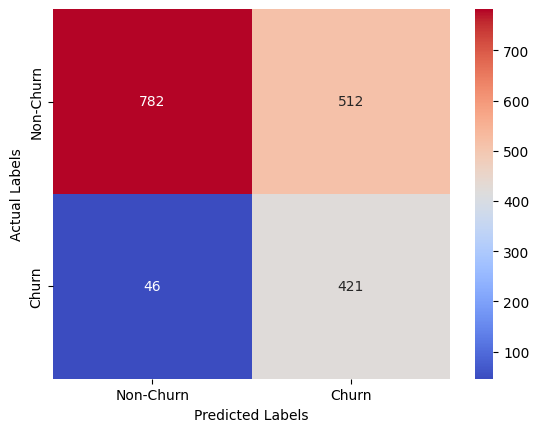

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
model = LogisticRegression(max_iter=10000, class_weight={0: 1, 1: 5})
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(data=cm, cmap='coolwarm', annot=True, fmt='d', xticklabels=['Non-Churn', 'Churn'], yticklabels=['Non-Churn', 'Churn'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()
